## 📦 Import All Modules

Add import statements for all available top-level modules

In [1]:
%matplotlib widget
from matplotlib import pyplot as plt
import numpy as np
import LADPackage
import examples
import shmtools

In [2]:
# [Baseline Waveforms, Test Waveforms, Sensor Layout, Sensor Pair List, Border Structure, Sample Rate, Actuation Waveform, Damage Location] = Import Active Sensing Dataset(File Name)
waveform_base, waveform_test, sensor_layout, pair_list, border_struct, sample_rate, actuation_waveform, damage_location = LADPackage.active_sensing.active_sensing_utils.import_active_sense_data(
    filename=None  # File Name (optional)
)

## Process Active Sensing Waveforms

Process active sensing waveforms with baseline subtraction and matched filtering.

In [3]:
# [Filter Result, Layout Subset, Sensor Pair Subset] = Process Active Sensing Waveforms (Sensor Subset List, Sensor Layout, Sensor Pair List, Baseline Waveforms, Test Waveforms, Excitation Waveform)
filter_result, layout_subset, pair_subset = LADPackage.active_sensing.active_sensing_utils.process_active_sensing_waveforms(
    sensor_subset=range(0,31,1),  # Sensor Subset List (required)
    sensor_layout=sensor_layout,  # Sensor Layout (required)
    pair_list=pair_list,  # Sensor Pair List (required)
    waveform_base=waveform_base,  # Baseline Waveforms (required)
    waveform_test=waveform_test,  # Test Waveforms (required)
    matched_waveform=actuation_waveform)

## Arrival Filter

Filter guided wave envelopes to first arrival.

In [4]:
# [Filtered Waveforms] = Arrival Filter (Waveforms, Front Clip, Arrival Offset)
filtered_waveforms = LADPackage.active_sensing.active_sensing_utils.arrival_filter(
    waveforms=filter_result,  # Waveforms (required)
    front_clip=450,  # Front Clip (optional)
    arrival_offset=450  # Arrival Offset (optional)
)

## Map Active Sensing Geometry

Map processed active sensing waveforms to geometry.

In [5]:
# [X Matrix, Y Matrix, Combined Geometry, Data Map 2D] = Map Active Sensing Map (Velocity, Subset Window, Distance Allowance, Geometry, X Spacing, Y Spacing, Sample Rate, Actuation Waveform, Data, Sensor Pair List, Sensor Layout)
x_matrix, y_matrix, combined_geometry, data_map_2d = LADPackage.active_sensing.active_sensing_utils.map_active_sensing_geometry(
    velocity=61000,  # Velocity (required)
    subset_window=None,  # Subset Window (required)
    distance_allowance=10000,  # Distance Allowance (required)
    border_struct=border_struct,  # Geometry (required)
    x_spacing=0.5,  # X Spacing (required)
    y_spacing=0.5,  # Y Spacing (required)
    sample_rate=sample_rate,  # Sample Rate Hz (required)
    actuation_waveform=None,  # Actuation Waveform (required)
    data=filtered_waveforms,  # Data (required)
    pair_list=pair_subset,  # Sensor Pair List (required)
    sensor_layout=layout_subset)

## Plot Active Sensing Map

Plot active sensing map with geometry.

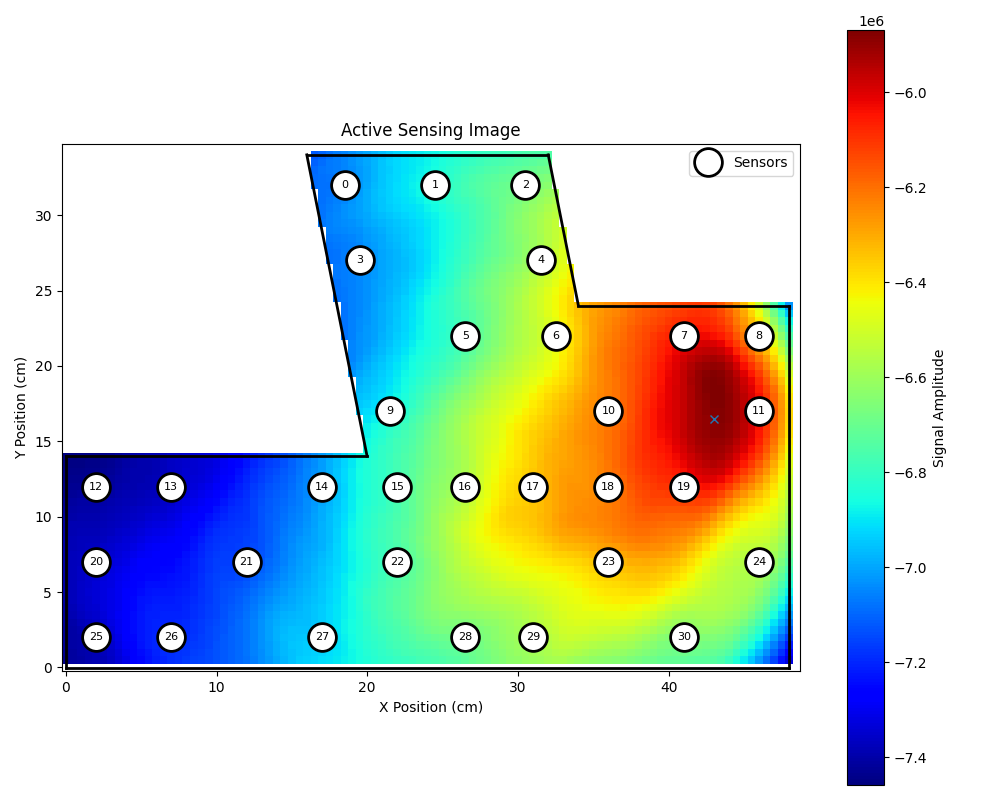

In [6]:
# Plot Active Sensing Map (X Matrix, Y Matrix, Data Map 2D, Border, Sensor Subset Layout)
result = LADPackage.active_sensing.active_sensing_utils.plot_as_result(
    x_matrix=x_matrix,  # <class 'numpy.ndarray'> (required)
    y_matrix=y_matrix,  # <class 'numpy.ndarray'> (required)
    data_map_2d=data_map_2d,  # <class 'numpy.ndarray'> (required)
    border=combined_geometry,  # <class 'numpy.ndarray'> (required)
    sensor_layout=layout_subset)

plt.plot(damage_location[0],damage_location[1],'x')